# 04 · SODAs — discovering Differential-Algebraic Equations

Real mechanistic models are often **DAEs**: differential equations *coupled with
algebraic constraints* (conservation laws, quasi-steady-state relations). The full
Michaelis–Menten mechanism

$$E + S \;\underset{k_r}{\overset{k}{\rightleftharpoons}}\; ES \;\xrightarrow{k_{cat}}\; E + P$$

has, in its quasi-steady-state form, an **algebraic** relation between species and a
**differential** law for the product.

**SODAs** (Jayadharan et al., *Proc. R. Soc. A* 2026) discovers this in the right order:
first the **algebraic constraints**, then — after using them to remove redundant library
terms — the **dynamics**. This sequence of convex problems keeps the recovered model
physically structured. We use the reference implementation, **`DaeFinder`**.

Ground-truth rates here: $k = k_r = k_{cat} = 1$, so the quasi-steady-state constraint is
$k\,[S][E] = (k_r + k_{cat})[ES]\Rightarrow [ES] = 0.5\,[S][E]$, enzyme conservation is
$[E] + [ES] = E_0$, and the product law is $d[P]/dt = k_{cat}[ES] = 1.0\,[ES]$.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

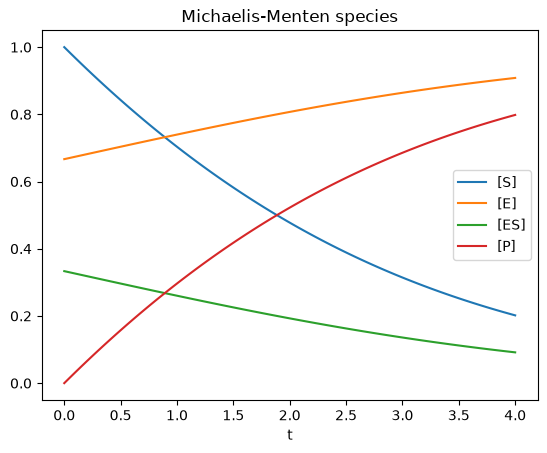

,[S],[E],[ES],[P],[t]
0,1.000000,0.666667,0.333333,0.000000,0.000000
1,0.983217,0.670417,0.329583,0.016783,0.050633
2,0.966624,0.674167,0.325833,0.033376,0.101266
3,0.950222,0.677915,0.322085,0.049778,0.151899
4,0.934008,0.681661,0.318339,0.065992,0.202532


In [3]:
import pandas as pd
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix,
                       AlgModelFinder, sequentialThLin)

# Generate Michaelis-Menten data: columns [S], [E], [ES], [P].
k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
IC      = pd.Series({"S": 1.0, "P": 0.0, "E": 1.0})
tg = np.linspace(0, 4, 80)
species = ["[S]", "[E]", "[ES]", "[P]"]
data = pd.DataFrame(solveMM(IC, k_rates, tg, "demo"), columns=species)
data["[t]"] = tg

for c in species:
    plt.plot(tg, data[c], label=c)
plt.legend(); plt.xlabel("t"); plt.title("Michaelis-Menten species"); plt.show()
data.head()

## Step 0 — smooth and differentiate

`smooth_data` fits splines and returns smoothed states **and** their derivatives
(`d([P]) /dt`, etc.), which we will need for the dynamic equations.

In [4]:
smooth = smooth_data(data, domain_var="[t]", derr_order=1, noise_perc=0, eval_points=tg)
print("smoothed / derivative columns:", list(smooth.columns))

smoothed / derivative columns: ['[t]', '[S]', 'd([S]) /dt', '[E]', 'd([E]) /dt', '[ES]', 'd([ES]) /dt', '[P]', 'd([P]) /dt']


## Step 1 — build the candidate library and discover ALGEBRAIC constraints

`AlgModelFinder` tries each library feature as the left-hand side and finds sparse
relations among the others. We drive it with a thresholded fit (`sequentialThLin`) so
the algebraic laws come out sparse.

In [5]:
lib = PolyFeatureMatrix(degree=2).fit_transform(data[species])
print("library terms:", list(lib.columns))

seq = sequentialThLin(model_id="lasso", coef_threshold=0.1, fit_intercept=True, alpha=0.05)
alg = AlgModelFinder(custom_model=True, custom_model_ob=seq)
alg.fit(lib, scale_columns=True)
best = alg.best_models(num=3)
print("\nTop algebraic relations (sparse coefficients, standardized):")
print(best.loc[(best != 0).any(axis=1)])

library terms: ['1', '[S]', '[E]', '[ES]', '[P]', '[S]^2', '[S] [E]', '[S] [ES]', '[S] [P]', '[E]^2', '[E] [ES]', '[E] [P]', '[ES]^2', '[ES] [P]', '[P]^2']
Sequential threshold converged in 1 iterations
Sequential threshold converged in 3 iterations
Sequential threshold converged in 3 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 3 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 3 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations

Top algebraic relations (sparse coefficients, standardized):
              1     [E]     [P]
[S]         0.0  0.0000 -0.9500
[E]         0.0     NaN  0.0000
[ES]        0.0 -0.9500  0.0

In [6]:
# The quasi-steady-state law explicitly: regress [ES] on the product [S][E].
qssa = sequentialThLin(model_id="LR", coef_threshold=0.05, fit_intercept=False)
qssa.fit(X=lib[["[S] [E]"]], y=lib["[ES]"])
print("QSSA constraint:  [ES] =",
      round(float(qssa.coef_[0]), 3), "* [S][E]   (true: 0.5)")
print("Enzyme conservation appears as a constant relation  [E] + [ES] = E_0.")

Sequential threshold converged in 0 iterations
QSSA constraint:  [ES] = 0.5 * [S][E]   (true: 0.5)
Enzyme conservation appears as a constant relation  [E] + [ES] = E_0.


## Step 2 — refine the library, then discover the DYNAMICS

The constraints tell us some species are *redundant*: enzyme conservation makes `[E]`
determined by `[ES]`. If we naively fit the dynamics on the full library, collinearity
lets the regression pick a wrong (but equivalent-on-this-data) representation. SODAs
**removes the algebraically-determined terms first** — here we drop `[E]` — and *then*
fits the differential equations. (`DaeFinder.get_refined_lib` automates this symbolic
elimination; we do it explicitly for clarity.)

In [7]:
refined_cols = ["[S]", "[ES]", "[P]"]   # [E] removed via enzyme conservation

for target, truth in [("d([P]) /dt", "+1.0 [ES]"), ("d([S]) /dt", "-1.0 [ES]")]:
    dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
    dyn.fit(X=lib[refined_cols], y=smooth[target])
    terms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_)
             if abs(c) > 1e-3}
    print(f"{target} = {terms}   (true: {truth})")

Sequential threshold converged in 1 iterations
d([P]) /dt = {'[ES]': 1.0}   (true: +1.0 [ES])
Sequential threshold converged in 1 iterations
d([S]) /dt = {'[ES]': -1.0}   (true: -1.0 [ES])


**Takeaway.** SODAs recovered the complete DAE — the quasi-steady-state algebraic
constraint *and* the differential product law — by solving algebra first and using it
to clean up the dynamics. This staged, convex approach is what lets it preserve physical
structure on constrained systems where one-shot SINDy variants get confused.

Next: a side-by-side comparison of all four methods. → `05_benchmark_comparison.ipynb`